In [15]:
import glob
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
from pyproj import Proj
import xarray
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.feature as cf
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

from global_land_mask import globe

import seaborn as sns

In [ ]:
qa = "aerdt_aod_qa3"
FILE_AHI_agg = f"AGGR_HOURLY_2019236_273_0_25deg_camp2ex_{qa}_FINAL_peat_0.14BA.nc"
C_AHI_agg = xarray.open_dataset(FILE_AHI_agg)
C_AHI_agg

<xarray.Dataset>
Dimensions:    (longitude: 186, latitude: 158)
Coordinates:
  * longitude  (longitude) float64 93.94 94.19 94.44 94.69 ... 139.7 140.0 140.2
  * latitude   (latitude) float64 -19.15 -18.9 -18.65 -18.4 ... 19.65 19.9 20.15
Data variables:
    aod_Mean   (latitude, longitude) float64 ...

In [ ]:
FILE_MUSICAv0_agg = f"AGGR_HOURLY_2019236_273_0_25deg_camp2ex_MUSICAv0_{qa}.nc"
C_MUSICAv0_agg = xarray.open_dataset(FILE_MUSICAv0_agg)
C_MUSICAv0_agg 


<xarray.Dataset>
Dimensions:  (lat: 158, lon: 186)
Coordinates:
  * lat      (lat) float32 -19.15 -18.9 -18.65 -18.4 ... 19.4 19.65 19.9 20.15
  * lon      (lon) float32 93.94 94.19 94.44 94.69 ... 139.5 139.7 140.0 140.2
Data variables:
    AODVIS   (lat, lon) float32 ...

In [ ]:
FILE_MUSICAv0_agg_exp01 = f"AGGR_HOURLY_2019236_273_0_25deg_camp2ex_MUSICAv0_{qa}_FINAL_peat_0.14BA.nc"
C_MUSICAv0_agg_exp01 = xarray.open_dataset(FILE_MUSICAv0_agg_exp01)
C_MUSICAv0_agg_exp01 


<xarray.Dataset>
Dimensions:  (lat: 158, lon: 186)
Coordinates:
  * lat      (lat) float32 -19.15 -18.9 -18.65 -18.4 ... 19.4 19.65 19.9 20.15
  * lon      (lon) float32 93.94 94.19 94.44 94.69 ... 139.5 139.7 140.0 140.2
Data variables:
    AODVIS   (lat, lon) float32 ...

In [19]:
mean_aod = C_AHI_agg['aod_Mean']
mean_aod_model = C_MUSICAv0_agg['AODVIS']
mean_aod_model_exp01 = C_MUSICAv0_agg_exp01['AODVIS']


In [21]:
bins = np.arange(0, 2.2, 0.2)
#all points (land and ocean)
df_mean_aod_ctrl = mean_aod_model.to_dataframe().reset_index().reset_index()
df_mean_aod_exp01 = mean_aod_model_exp01.to_dataframe().reset_index().reset_index()
df_mean_aod_obs = mean_aod.to_dataframe().reset_index().reset_index()
merged_df_ctrl = pd.merge(df_mean_aod_obs, df_mean_aod_ctrl, on=['index'], how='inner')
merged_df_exp01 = pd.merge(df_mean_aod_obs, df_mean_aod_exp01, on=['index'], how='inner')
merged_df_no_nan_ctrl = merged_df_ctrl[['index','AODVIS','aod_Mean']].dropna()
merged_df_no_nan_exp01 = merged_df_exp01[['index','AODVIS','aod_Mean']].dropna()
merged_df_no_nan_ctrl['aod_obs_bin'] = pd.cut(merged_df_no_nan_ctrl['aod_Mean'], bins)
grouped_df = merged_df_no_nan_ctrl.groupby('aod_obs_bin').mean()
grouped_df = grouped_df.reset_index()
grouped_df_std = merged_df_no_nan_ctrl.groupby('aod_obs_bin').std()
grouped_df_std = grouped_df_std.reset_index()

In [26]:
#ocean points only
o_mean_aod_obs = mean_aod
o_mean_aod_ctrl = mean_aod_model
o_mean_aod_exp01 = mean_aod_model_exp01

for latitude in mean_aod.latitude:
    for longitude in mean_aod.longitude:
        if globe.is_land(latitude.item(), longitude.item()):
            o_mean_aod_ctrl.loc[dict(lat=latitude, lon=longitude)] = np.nan
            o_mean_aod_exp01.loc[dict(lat=latitude, lon=longitude)] = np.nan
            o_mean_aod_obs.loc[dict(latitude=latitude, longitude=longitude)] = np.nan
o_df_mean_aod_ctrl = o_mean_aod_ctrl.to_dataframe().reset_index().reset_index()
o_df_mean_aod_exp01 = o_mean_aod_exp01.to_dataframe().reset_index().reset_index()
o_df_mean_aod_obs = o_mean_aod_obs.to_dataframe().reset_index().reset_index()
o_merged_df_ctrl = pd.merge(o_df_mean_aod_obs, o_df_mean_aod_ctrl, on=['index'], how='inner')
o_merged_df_exp01 = pd.merge(o_df_mean_aod_obs, o_df_mean_aod_exp01, on=['index'], how='inner')
o_merged_df_no_nan_ctrl = o_merged_df_ctrl[['index','AODVIS','aod_Mean']].dropna()
o_merged_df_no_nan_exp01 = o_merged_df_exp01[['index','AODVIS','aod_Mean']].dropna()
o_merged_df_no_nan_ctrl['aod_obs_bin'] = pd.cut(o_merged_df_no_nan_ctrl['aod_Mean'], bins)
o_grouped_df_ctrl = o_merged_df_no_nan_ctrl.groupby('aod_obs_bin').mean()
o_grouped_df_ctrl = o_grouped_df_ctrl.reset_index()
o_grouped_df_std_ctrl = o_merged_df_no_nan_ctrl.groupby('aod_obs_bin').std()
o_grouped_df_std_ctrl = o_grouped_df_std_ctrl.reset_index()    
o_merged_df_no_nan_exp01['aod_obs_bin'] = pd.cut(o_merged_df_no_nan_exp01['aod_Mean'], bins)
o_grouped_df_exp01 = o_merged_df_no_nan_exp01.groupby('aod_obs_bin').mean()
o_grouped_df_exp01 = o_grouped_df_exp01.reset_index()
o_grouped_df_std_exp01 = o_merged_df_no_nan_exp01.groupby('aod_obs_bin').std()
o_grouped_df_std_exp01 = o_grouped_df_std_exp01.reset_index()    

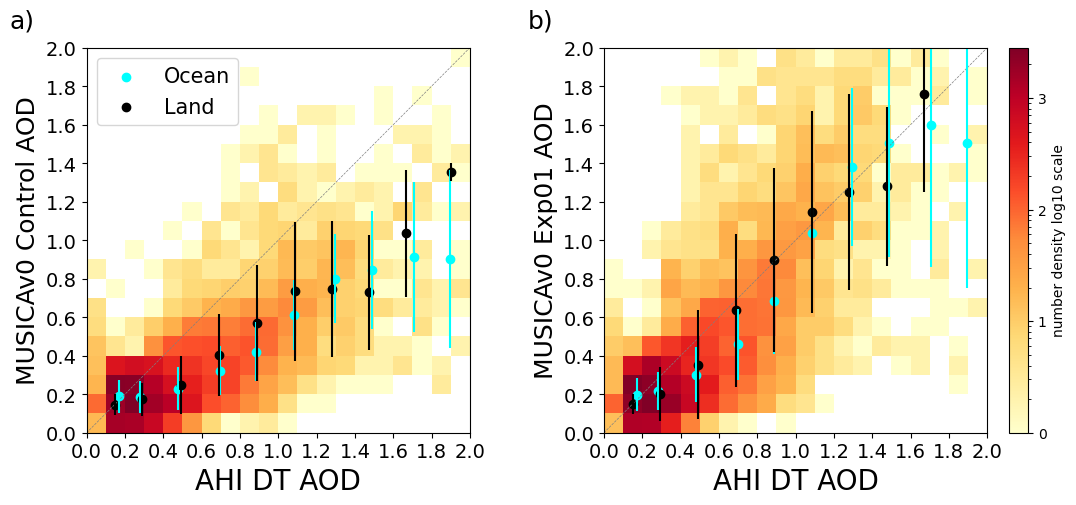

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

fig.subplots_adjust(wspace=0.35)   # increase spacing between panels

# -------------------------
# PANEL 1 (left)
# -------------------------
bins = np.arange(0, 2.1, 0.1)

h = ax1.hist2d(
    merged_df_no_nan_ctrl['aod_Mean'],
    merged_df_no_nan_ctrl['AODVIS'],
    bins=[bins, bins],
    cmap='YlOrRd',
    norm=LogNorm()
)


# 1:1 line
ax1.plot([0, 3], [0, 3], color='gray', linestyle='--', linewidth=0.5)

aerdt_land_mean = pd.read_csv('/home/svisaga/MUSICA_Paper1_2025/output/csv/aerdt_land_mean.csv')
aerdt_land_std = pd.read_csv('/home/svisaga/MUSICA_Paper1_2025/output/csv/aerdt_land_std.csv')
# Scatter points
ax1.scatter(o_grouped_df_ctrl['aod_Mean'], o_grouped_df_ctrl['AODVIS'],
            color='#00FFFF', label='Ocean')
ax1.scatter(aerdt_land_mean['aod_Mean'], aerdt_land_mean['AODVIS'],
            color='k', label='Land')

# Vertical error bars
for i in range(len(grouped_df)):
    ax1.vlines(
        x=o_grouped_df_ctrl['aod_Mean'][i],
        ymin=o_grouped_df_ctrl['AODVIS'][i] - o_grouped_df_std_ctrl['AODVIS'][i],
        ymax=o_grouped_df_ctrl['AODVIS'][i] + o_grouped_df_std_ctrl['AODVIS'][i],
        color='#00FFFF'
    )
for i in range(len(aerdt_land_mean)):
    ax1.vlines(
        x=aerdt_land_mean['aod_Mean'][i],
        ymin=aerdt_land_mean['AODVIS'][i] - aerdt_land_std['AODVIS'][i],
        ymax=aerdt_land_mean['AODVIS'][i] + aerdt_land_std['AODVIS'][i],
        color='k'
    )

ax1.set_xlabel('AHI DT AOD', fontsize=20)
ax1.set_ylabel('MUSICAv0 Control AOD', fontsize=18)
ax1.set_xlim(0, 2)
ax1.set_ylim(0, 2)
ax1.set_xticks(np.arange(0, 2.1, 0.2))
ax1.set_yticks(np.arange(0, 2.1, 0.2))
ax1.tick_params(labelsize=14)
ax1.legend(fontsize=15)

# -------------------------
# PANEL 2 (right)
# -------------------------
# PANEL 2
h2 = ax2.hist2d(
    merged_df_no_nan_exp01['aod_Mean'],
    merged_df_no_nan_exp01['AODVIS'],
    bins=[bins, bins],
    cmap='YlOrRd',
    norm=LogNorm()
)

# Colorbar for the whole figure, placed to the right
cbar = fig.colorbar(h2[3], ax=[ax1, ax2], pad=0.02, label='number density log10 scale')

cbar.set_ticks([1, 10, 100, 1000])
cbar.set_ticklabels(['0', '1', '2', '3'])

# 1:1 line
ax2.plot([0, 3], [0, 3], color='gray', linestyle='--', linewidth=0.5)
aerdt_land_mean = pd.read_csv('/home/svisaga/MUSICA_Paper1_figures_for_Exp01/output/csv/aerdt_land_mean.csv')
aerdt_land_std = pd.read_csv('/home/svisaga/MUSICA_Paper1_figures_for_Exp01/output/csv/aerdt_land_std.csv')
# Scatter points
ax2.scatter(o_grouped_df_exp01['aod_Mean'], o_grouped_df_exp01['AODVIS'],
            color='#00FFFF', label='Ocean')
ax2.scatter(aerdt_land_mean['aod_Mean'], aerdt_land_mean['AODVIS'],
            color='k', label='Land')

# Vertical error bars
for i in range(len(grouped_df)):
    ax2.vlines(
        x=o_grouped_df_exp01['aod_Mean'][i],
        ymin=o_grouped_df_exp01['AODVIS'][i] - o_grouped_df_std_exp01['AODVIS'][i],
        ymax=o_grouped_df_exp01['AODVIS'][i] + o_grouped_df_std_exp01['AODVIS'][i],
        color='#00FFFF'
    )
for i in range(len(aerdt_land_mean)):
    ax2.vlines(
        x=aerdt_land_mean['aod_Mean'][i],
        ymin=aerdt_land_mean['AODVIS'][i] - aerdt_land_std['AODVIS'][i],
        ymax=aerdt_land_mean['AODVIS'][i] + aerdt_land_std['AODVIS'][i],
        color='k'
    )

ax2.set_xlabel('AHI DT AOD', fontsize=20)
ax2.set_ylabel('MUSICAv0 Exp01 AOD', fontsize=18)
ax2.set_xlim(0, 2)
ax2.set_ylim(0, 2)
ax2.set_xticks(np.arange(0, 2.1, 0.2))
ax2.set_yticks(np.arange(0, 2.1, 0.2))
ax2.tick_params(labelsize=14)


ax1.text(-0.2, 1.1, 'a)', transform=ax1.transAxes,
         fontsize=18, va='top', ha='left')

ax2.text(-0.2, 1.1, 'b)', transform=ax2.transAxes,
         fontsize=18,  va='top', ha='left')

plt.savefig('output/img/Figure3_AMSPaper.png', dpi=300, bbox_inches='tight')
